# Mining Quality Prediction — Data Audit

**Objective.** Predict `% Silica Concentrate`, the impurity fraction of the iron ore concentrate produced by a froth flotation circuit.

**Business framing.** A model that predicts `% Silica Concentrate` from process sensor data would act as a soft sensor, giving plant operators earlier visibility into concentrate quality than the hourly laboratory assay currently provides, without waiting for the physical lab result.

**Raw data source.** Kaggle public dataset, *Quality Prediction in a Mining Process*.

**Raw dataset path.** `data/raw/MiningProcess_Flotation_Plant_Database.csv`, relative to the repository root.

**Scope of this notebook.** This notebook performs exploratory auditing only. It reproduces the data structure and temporal findings needed to understand what the raw rows represent before any cleaning, feature engineering, splitting, or modeling decision is made. It does not build a model, produce a processed dataset, or implement the production preprocessing pipeline.

## 2. Imports and Configuration

In [34]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

In [35]:
RAW_DATA_PATH = Path("../data/raw/MiningProcess_Flotation_Plant_Database.csv")

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError("Raw mining dataset not found.")

print("Raw data available:", RAW_DATA_PATH.exists())

Raw data available: True


## 3. Load Raw Data

The raw CSV uses a comma as the decimal separator, so numeric columns must be parsed with `decimal=","`.

In [36]:
df = pd.read_csv(RAW_DATA_PATH, decimal=",", parse_dates=["date"])
df.shape

(737453, 24)

In [37]:
df.head()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,Flotation Column 04 Air Flow,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,250.576,295.096,306.4,250.225,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,250.862,295.096,306.4,250.137,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2,2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,250.313,295.096,306.4,251.345,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
3,2017-03-10 01:00:00,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,250.049,295.096,306.4,250.422,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
4,2017-03-10 01:00:00,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,250.203,252.136,249.895,295.096,306.4,249.983,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31


In [38]:
list(df.columns)

['date',
 '% Iron Feed',
 '% Silica Feed',
 'Starch Flow',
 'Amina Flow',
 'Ore Pulp Flow',
 'Ore Pulp pH',
 'Ore Pulp Density',
 'Flotation Column 01 Air Flow',
 'Flotation Column 02 Air Flow',
 'Flotation Column 03 Air Flow',
 'Flotation Column 04 Air Flow',
 'Flotation Column 05 Air Flow',
 'Flotation Column 06 Air Flow',
 'Flotation Column 07 Air Flow',
 'Flotation Column 01 Level',
 'Flotation Column 02 Level',
 'Flotation Column 03 Level',
 'Flotation Column 04 Level',
 'Flotation Column 05 Level',
 'Flotation Column 06 Level',
 'Flotation Column 07 Level',
 '% Iron Concentrate',
 '% Silica Concentrate']

In [39]:
df.dtypes

date                            datetime64[ns]
% Iron Feed                            float64
% Silica Feed                          float64
Starch Flow                            float64
Amina Flow                             float64
Ore Pulp Flow                          float64
Ore Pulp pH                            float64
Ore Pulp Density                       float64
Flotation Column 01 Air Flow           float64
Flotation Column 02 Air Flow           float64
Flotation Column 03 Air Flow           float64
Flotation Column 04 Air Flow           float64
Flotation Column 05 Air Flow           float64
Flotation Column 06 Air Flow           float64
Flotation Column 07 Air Flow           float64
Flotation Column 01 Level              float64
Flotation Column 02 Level              float64
Flotation Column 03 Level              float64
Flotation Column 04 Level              float64
Flotation Column 05 Level              float64
Flotation Column 06 Level              float64
Flotation Col

## 4. Basic Data Quality

Two duplicate counts are reported and must not be conflated:

- **Rows involved in duplicate sets** — every row that has at least one exact twin elsewhere in the file, including the first occurrence of each repeated value.
- **Redundant duplicate copies** — the number of *excess* rows that would be removed if each duplicate set were collapsed down to a single representative row.

In [40]:
row_count, col_count = df.shape
missing_by_column = df.isna().sum()
total_missing = int(missing_by_column.sum())

print("Row count:", row_count)
print("Column count:", col_count)
print("Total missing cells:", total_missing)
missing_by_column

Row count: 737453
Column count: 24
Total missing cells: 0


date                            0
% Iron Feed                     0
% Silica Feed                   0
Starch Flow                     0
Amina Flow                      0
Ore Pulp Flow                   0
Ore Pulp pH                     0
Ore Pulp Density                0
Flotation Column 01 Air Flow    0
Flotation Column 02 Air Flow    0
Flotation Column 03 Air Flow    0
Flotation Column 04 Air Flow    0
Flotation Column 05 Air Flow    0
Flotation Column 06 Air Flow    0
Flotation Column 07 Air Flow    0
Flotation Column 01 Level       0
Flotation Column 02 Level       0
Flotation Column 03 Level       0
Flotation Column 04 Level       0
Flotation Column 05 Level       0
Flotation Column 06 Level       0
Flotation Column 07 Level       0
% Iron Concentrate              0
% Silica Concentrate            0
dtype: int64

In [41]:
rows_in_duplicate_sets = int(df.duplicated(keep=False).sum())
redundant_duplicate_copies = int(df.duplicated(keep="first").sum())

print("Rows involved in duplicate sets:", rows_in_duplicate_sets)
print("Redundant duplicate copies:", redundant_duplicate_copies)
print(f"Redundant copies as % of all rows: {100 * redundant_duplicate_copies / row_count:.4f}%")

Rows involved in duplicate sets: 1186
Redundant duplicate copies: 1171
Redundant copies as % of all rows: 0.1588%


In [42]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,737453,2017-06-16 03:27:22.656549376,2017-03-10 01:00:00,2017-05-04 23:00:00,2017-06-16 15:00:00,2017-07-29 07:00:00,2017-09-09 23:00:00,NaN
% Iron Feed,737453.0,56.294739,42.74,52.67,56.08,59.72,65.78,5.157744
% Silica Feed,737453.0,14.651716,1.31,8.94,13.85,19.6,33.4,6.807439
Starch Flow,737453.0,2869.140569,0.002026,2076.32,3018.43,3727.73,6300.23,1215.203734
Amina Flow,737453.0,488.144697,241.669,431.796,504.393,553.257,739.538,91.230534
Ore Pulp Flow,737453.0,397.578372,376.249,394.264,399.249,402.968,418.641,9.699785
Ore Pulp pH,737453.0,9.767639,8.75334,9.52736,9.7981,10.038,10.8081,0.387007
Ore Pulp Density,737453.0,1.68038,1.51982,1.64731,1.6976,1.72833,1.85325,0.069249
Flotation Column 01 Air Flow,737453.0,280.151856,175.51,250.281,299.344,300.149,373.871,29.621288
Flotation Column 02 Air Flow,737453.0,277.159965,175.156,250.457,296.223,300.69,375.992,30.149357


## 5. Temporal Structure

`date` is parsed as a timestamp at load time (Section 3). This section documents the timestamp grid the raw rows sit on.

In [43]:
unique_timestamps = df["date"].nunique()
min_date = df["date"].min()
max_date = df["date"].max()
is_sorted = df["date"].is_monotonic_increasing

print("Unique timestamps:", unique_timestamps)
print("Minimum date:", min_date)
print("Maximum date:", max_date)
print("Timestamps sorted (non-decreasing) in file order:", is_sorted)

Unique timestamps: 4097
Minimum date: 2017-03-10 01:00:00
Maximum date: 2017-09-09 23:00:00
Timestamps sorted (non-decreasing) in file order: True


In [44]:
rows_per_timestamp = df.groupby("date").size()
rows_per_timestamp.describe()

count    4097.000000
mean      179.998291
std         0.095028
min       174.000000
25%       180.000000
50%       180.000000
75%       180.000000
max       180.000000
dtype: float64

**180 rows per hour pattern.** The distribution above is expected to be overwhelmingly concentrated at 180 rows per timestamp. The cell below isolates any timestamp that departs from that count.

In [45]:
anomalous_counts = rows_per_timestamp[rows_per_timestamp != 180].sort_index()
anomalous_counts

date
2017-03-10 01:00:00    174
2017-04-10 00:00:00    179
dtype: int64

Two specific timestamps are called out here because they are the only departures from the 180 row pattern in the file: the first timestamp in the dataset (`2017-03-10 01:00:00`), which carries only 174 rows, plausibly because the file begins partway through that hour's acquisition window, and a single mid sequence timestamp (`2017-04-10 00:00:00`), which carries 179 rows with no adjacent gap or other structural anomaly to explain the one missing row.

In [46]:
first_timestamp = df["date"].min()
check_timestamp = pd.Timestamp("2017-04-10 00:00:00")

print("First timestamp:", first_timestamp, "-> rows:", int(rows_per_timestamp.loc[first_timestamp]))
print("2017-04-10 00:00:00 -> rows:", int(rows_per_timestamp.loc[check_timestamp]))

First timestamp: 2017-03-10 01:00:00 -> rows: 174
2017-04-10 00:00:00 -> rows: 179


**Inferred 20 second sensor cadence.** Each hourly timestamp is stamped once per hour, yet is associated with 180 rows in the overwhelming majority of cases. Dividing the 3,600 seconds in an hour by 180 rows gives 20 seconds. This 20 second cadence is **an inference supported by the observed 180 rows per hour structure**, not a fact recorded anywhere in the raw file: the `date` column itself carries only hourly resolution, and no sub-hour timestamp exists to confirm the spacing directly.

In [47]:
implied_seconds_per_row = 3600 / rows_per_timestamp.mode().iloc[0]
print(f"3600 seconds / {int(rows_per_timestamp.mode().iloc[0])} modal rows per hour = "
      f"{implied_seconds_per_row:.1f} seconds per row (inferred, not directly recorded)")

3600 seconds / 180 modal rows per hour = 20.0 seconds per row (inferred, not directly recorded)


## 6. Temporal Gaps

Consecutive differences between *unique* timestamps reveal whether the hourly grid established in Section 5 is continuous.

In [48]:
unique_ts_sorted = pd.Series(sorted(df["date"].unique()))
gap_sizes = unique_ts_sorted.diff().dropna()
gap_sizes.value_counts().sort_index()

0 days 01:00:00     4095
13 days 07:00:00       1
Name: count, dtype: int64

In [49]:
modal_interval = gap_sizes.mode().iloc[0]
large_gaps = gap_sizes[gap_sizes > modal_interval]

print("Normal interval between consecutive timestamps:", modal_interval)
print("Number of gaps larger than the normal interval:", len(large_gaps))

for idx in large_gaps.index:
    gap_start = unique_ts_sorted.iloc[idx - 1]
    gap_end = unique_ts_sorted.iloc[idx]
    print(f"Gap: {gap_end - gap_start} between {gap_start} and {gap_end}")

Normal interval between consecutive timestamps: 0 days 01:00:00
Number of gaps larger than the normal interval: 1
Gap: 13 days 07:00:00 between 2017-03-16 05:00:00 and 2017-03-29 12:00:00


**Two continuous operating periods.** The single large gap above splits the file into two contiguous blocks of hourly timestamps.

In [50]:
gap_boundary_start = unique_ts_sorted.iloc[large_gaps.index[0] - 1]
gap_boundary_end = unique_ts_sorted.iloc[large_gaps.index[0]]

period_1 = df[df["date"] <= gap_boundary_start]
period_2 = df[df["date"] >= gap_boundary_end]

print(f"Period 1: {period_1['date'].min()} to {period_1['date'].max()} "
      f"({len(period_1):,} rows, {100 * len(period_1) / row_count:.1f}% of the file)")
print(f"Period 2: {period_2['date'].min()} to {period_2['date'].max()} "
      f"({len(period_2):,} rows, {100 * len(period_2) / row_count:.1f}% of the file)")

Period 1: 2017-03-10 01:00:00 to 2017-03-16 05:00:00 (26,814 rows, 3.6% of the file)
Period 2: 2017-03-29 12:00:00 to 2017-09-09 23:00:00 (710,639 rows, 96.4% of the file)


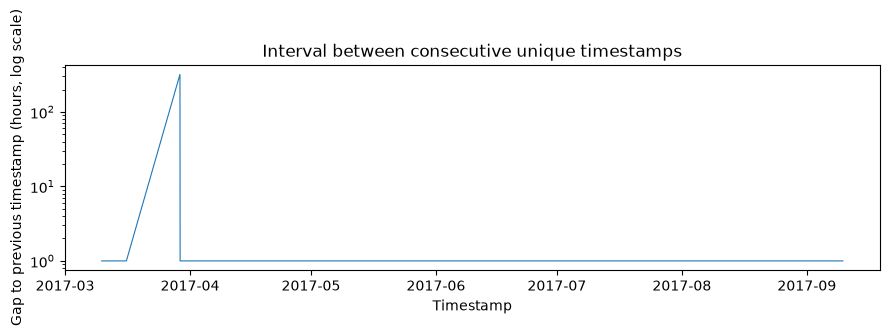

In [51]:
fig, ax = plt.subplots(figsize=(9, 3))
gap_hours = gap_sizes.dt.total_seconds() / 3600
ax.plot(unique_ts_sorted.iloc[1:], gap_hours, linewidth=0.8)
ax.set_yscale("log")
ax.set_ylabel("Gap to previous timestamp (hours, log scale)")
ax.set_xlabel("Timestamp")
ax.set_title("Interval between consecutive unique timestamps")
fig.tight_layout()
plt.show()

## 7. Target Analysis

Both concentrate columns are analyzed: `% Silica Concentrate`, the proposed target, and `% Iron Concentrate`, which is examined here purely for its statistical behavior. Whether it is admissible as a predictor is addressed separately in Section 10.

In [52]:
target_cols = ["% Silica Concentrate", "% Iron Concentrate"]
df[target_cols].describe()

,% Silica Concentrate,% Iron Concentrate
count,737453.000000,737453.000000
mean,2.326763,65.050068
std,1.125554,1.118645
min,0.600000,62.050000
25%,1.440000,64.370000
50%,2.000000,65.210000
75%,3.010000,65.860000
max,5.530000,68.010000


In [53]:
for col in target_cols:
    print(f"{col}: {df[col].nunique():,} unique values, range [{df[col].min()}, {df[col].max()}]")

target_correlation = df["% Iron Concentrate"].corr(df["% Silica Concentrate"])
print(f"\nPearson correlation between the two concentrate columns: {target_correlation:.4f}")

% Silica Concentrate: 55,569 unique values, range [0.6, 5.53]
% Iron Concentrate: 38,696 unique values, range [62.05, 68.01]

Pearson correlation between the two concentrate columns: -0.8006


### Within hour behavior

For each target, the fraction of hourly timestamps where the value is constant across all rows in that hour.

In [54]:
within_hour_summary = {}
for col in target_cols:
    nunique_per_hour = df.groupby("date")[col].nunique()
    n_constant_hours = int((nunique_per_hour == 1).sum())
    n_total_hours = len(nunique_per_hour)
    within_hour_summary[col] = (n_constant_hours, n_total_hours)
    print(f"{col}: constant in {n_constant_hours:,} / {n_total_hours:,} hours "
          f"({100 * n_constant_hours / n_total_hours:.1f}%)")

% Silica Concentrate: constant in 3,787 / 4,097 hours (92.4%)
% Iron Concentrate: constant in 3,881 / 4,097 hours (94.7%)


### Consecutive target holding behavior

Grouping consecutive rows that share an identical target value (in raw file order, not per hour) shows how long a given lab value is held before it changes.

In [55]:
def block_lengths(series: pd.Series) -> pd.Series:
    """Length of each run of consecutive, identical values in row order."""
    change_points = series.ne(series.shift()).cumsum()
    return series.groupby(change_points).size()


for col in target_cols:
    lengths = block_lengths(df[col])
    distinct_lengths = sorted(lengths.unique())
    print(f"{col}: {len(lengths):,} holding blocks")
    print(f"  Distinct block lengths present: {distinct_lengths}")
    print(f"  Longest holding block: {lengths.max():,} rows "
          f"(~{lengths.max() / rows_per_timestamp.mode().iloc[0]:.1f} hours)\n")

% Silica Concentrate: 59,141 holding blocks
  Distinct block lengths present: [np.int64(1), np.int64(174), np.int64(180), np.int64(359), np.int64(360), np.int64(540), np.int64(720), np.int64(900), np.int64(1080), np.int64(1620), np.int64(1800), np.int64(2340), np.int64(2520), np.int64(2700), np.int64(2880), np.int64(3060), np.int64(3420), np.int64(5040), np.int64(7020), np.int64(13140)]
  Longest holding block: 13,140 rows (~73.0 hours)

% Iron Concentrate: 42,308 holding blocks
  Distinct block lengths present: [np.int64(1), np.int64(174), np.int64(180), np.int64(359), np.int64(360), np.int64(540), np.int64(720), np.int64(900), np.int64(1080), np.int64(1260), np.int64(1620), np.int64(1800), np.int64(2340), np.int64(2520), np.int64(2700), np.int64(2880), np.int64(3060), np.int64(3420), np.int64(5040), np.int64(7020), np.int64(13320)]
  Longest holding block: 13,320 rows (~74.0 hours)



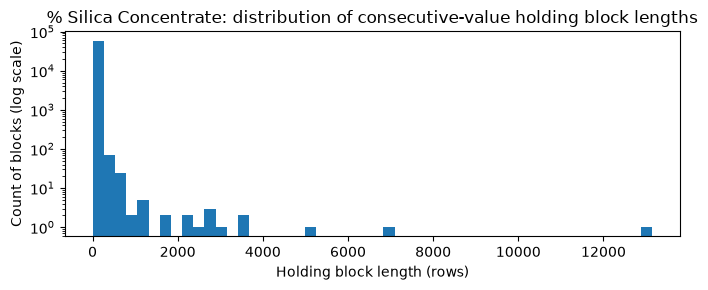

In [56]:
fig, ax = plt.subplots(figsize=(7, 3))
lengths = block_lengths(df["% Silica Concentrate"])
ax.hist(lengths, bins=50, log=True)
ax.set_xlabel("Holding block length (rows)")
ax.set_ylabel("Count of blocks (log scale)")
ax.set_title("% Silica Concentrate: distribution of consecutive-value holding block lengths")
fig.tight_layout()
plt.show()

### Programmatic linearity test for nonconstant hours

For every hour where the target is *not* constant, a first degree polynomial (straight line) is fit against row position within the hour. If the maximum absolute residual from that fit is small relative to the total range of values in the hour, the sequence is classified as quasi linear. This is applied to every nonconstant hour, not to a handful of inspected examples.

In [57]:
def linearity_report(df: pd.DataFrame, col: str, relative_residual_threshold: float = 0.01) -> pd.DataFrame:
    nunique_per_hour = df.groupby("date")[col].nunique()
    nonconstant_hours = nunique_per_hour[nunique_per_hour > 1].index

    records = []
    for ts in nonconstant_hours:
        values = df.loc[df["date"] == ts, col].to_numpy()
        x = np.arange(len(values))
        slope, intercept = np.polyfit(x, values, 1)
        fitted = slope * x + intercept
        max_abs_residual = np.max(np.abs(values - fitted))
        value_range = values.max() - values.min()
        normalized_residual = max_abs_residual / value_range if value_range > 0 else np.nan
        records.append({
            "timestamp": ts,
            "n_rows": len(values),
            "value_range": value_range,
            "max_abs_residual": max_abs_residual,
            "normalized_residual": normalized_residual,
            "quasi_linear": normalized_residual < relative_residual_threshold,
        })
    return pd.DataFrame.from_records(records)


for col in target_cols:
    report = linearity_report(df, col)
    n_linear = int(report["quasi_linear"].sum())
    n_total = len(report)
    print(f"{col}: {n_linear:,} / {n_total:,} nonconstant hours "
          f"({100 * n_linear / n_total:.1f}%) are quasi-linear "
          f"(max residual < 1% of the hour's value range)")
    print(report["normalized_residual"].describe())
    print()

% Silica Concentrate: 310 / 310 nonconstant hours (100.0%) are quasi-linear (max residual < 1% of the hour's value range)
count    3.100000e+02
mean     9.346899e-10
std      1.714750e-09
min      1.626658e-11
25%      1.288585e-10
50%      3.342875e-10
75%      8.968949e-10
max      1.103357e-08
Name: normalized_residual, dtype: float64

% Iron Concentrate: 216 / 216 nonconstant hours (100.0%) are quasi-linear (max residual < 1% of the hour's value range)
count    2.160000e+02
mean     7.724161e-10
std      1.246596e-09
min      2.778659e-14
25%      1.875558e-10
50%      3.815828e-10
75%      6.107679e-10
max      5.136225e-09
Name: normalized_residual, dtype: float64



**Finding.** The overwhelming majority of nonconstant hours fit an almost exact straight line against row position, with residuals many orders of magnitude smaller than the hour's value range. This behavior is consistent with deterministic linear interpolation between two hourly lab readings rather than with 180 independent 20 second laboratory measurements, which would not be expected to fall on an exact line. **The near exact linear progression is directly demonstrated by the residual test above. Interpolation between lower frequency measurements is the most plausible explanation, but the mechanism that produced these values cannot be confirmed from the CSV alone.**


## 8. Process Variable Behavior

Process columns are grouped into functional categories to compare their update behavior against the hourly targets analyzed above. No feature is removed or transformed in this section.

In [58]:
feed_chemistry = ["% Iron Feed", "% Silica Feed"]
reagent_and_pulp = ["Starch Flow", "Amina Flow", "Ore Pulp Flow", "Ore Pulp pH", "Ore Pulp Density"]
air_flow = [f"Flotation Column {i:02d} Air Flow" for i in range(1, 8)]
level = [f"Flotation Column {i:02d} Level" for i in range(1, 8)]
concentrate_outputs = ["% Iron Concentrate", "% Silica Concentrate"]

categories = {
    "Feed chemistry": feed_chemistry,
    "Reagent and pulp measurements": reagent_and_pulp,
    "Flotation air flow": air_flow,
    "Flotation level": level,
    "Concentrate laboratory outputs": concentrate_outputs,
}

assert sorted(sum(categories.values(), [])) == sorted(c for c in df.columns if c != "date")

In [59]:
fraction_varying_within_hour = {}
for col in df.columns:
    if col == "date":
        continue
    nunique_per_hour = df.groupby("date")[col].nunique()
    fraction_varying_within_hour[col] = float((nunique_per_hour > 1).mean())

variability_by_category = {
    category: {c: fraction_varying_within_hour[c] for c in cols}
    for category, cols in categories.items()
}

for category, values in variability_by_category.items():
    mean_fraction = np.mean(list(values.values()))
    print(f"{category}: mean fraction of hours with within-hour variation = {mean_fraction:.4f}")

pd.Series(fraction_varying_within_hour).sort_values()

Feed chemistry: mean fraction of hours with within-hour variation = 0.0000
Reagent and pulp measurements: mean fraction of hours with within-hour variation = 0.9982
Flotation air flow: mean fraction of hours with within-hour variation = 0.9655
Flotation level: mean fraction of hours with within-hour variation = 0.9988
Concentrate laboratory outputs: mean fraction of hours with within-hour variation = 0.0642


% Iron Feed                     0.000000
% Silica Feed                   0.000000
% Iron Concentrate              0.052722
% Silica Concentrate            0.075665
Flotation Column 04 Air Flow    0.886502
Flotation Column 05 Air Flow    0.886502
Ore Pulp pH                     0.996095
Flotation Column 07 Air Flow    0.996827
Flotation Column 06 Air Flow    0.996827
Flotation Column 01 Air Flow    0.997071
Flotation Column 02 Air Flow    0.997315
Flotation Column 03 Air Flow    0.997315
Flotation Column 01 Level       0.997803
Ore Pulp Density                0.998047
Flotation Column 05 Level       0.998536
Ore Pulp Flow                   0.999024
Flotation Column 02 Level       0.999024
Starch Flow                     0.999024
Amina Flow                      0.999024
Flotation Column 03 Level       0.999024
Flotation Column 06 Level       0.999024
Flotation Column 04 Level       0.999024
Flotation Column 07 Level       0.999024
dtype: float64

**Feed chemistry behaves like a batch level variable, not a high frequency sensor.** The two feed columns change within an hour in effectively none of the hours in the dataset (see the near zero fraction above), and the block length analysis below shows their holding blocks span many hours to multiple weeks, unlike the reagent, air flow, and level columns.

In [60]:
for col in feed_chemistry:
    lengths = block_lengths(df[col])
    print(f"{col}: {len(lengths)} holding blocks across the whole file")
    print(f"  Shortest block: {lengths.min():,} rows, longest block: {lengths.max():,} rows "
          f"(~{lengths.max() / rows_per_timestamp.mode().iloc[0] / 24:.1f} days)")

% Iron Feed: 307 holding blocks across the whole file
  Shortest block: 720 rows, longest block: 142,560 rows (~33.0 days)
% Silica Feed: 306 holding blocks across the whole file
  Shortest block: 720 rows, longest block: 142,560 rows (~33.0 days)


In [61]:
df[[c for c in df.columns if c != 'date']].describe().T[['min', 'mean', 'max', 'std']]

,min,mean,max,std
% Iron Feed,42.740000,56.294739,65.78000,5.157744
% Silica Feed,1.310000,14.651716,33.40000,6.807439
Starch Flow,0.002026,2869.140569,6300.23000,1215.203734
Amina Flow,241.669000,488.144697,739.53800,91.230534
Ore Pulp Flow,376.249000,397.578372,418.64100,9.699785
Ore Pulp pH,8.753340,9.767639,10.80810,0.387007
Ore Pulp Density,1.519820,1.680380,1.85325,0.069249
Flotation Column 01 Air Flow,175.510000,280.151856,373.87100,29.621288
Flotation Column 02 Air Flow,175.156000,277.159965,375.99200,30.149357
Flotation Column 03 Air Flow,176.469000,281.082397,364.34600,28.558268


## 9. Duplicate and Frozen Sensor Investigation

This section reproduces the exact duplicate analysis from Section 4 at the timestamp level, and inspects four specific hours in detail. No rows are modified or removed.

In [62]:
exact_dupe_mask = df.duplicated(keep=False)
dupes_by_timestamp = df.loc[exact_dupe_mask].groupby("date").size().sort_index()
dupes_by_timestamp

date
2017-03-12 01:00:00      2
2017-06-01 15:00:00      6
2017-06-28 15:00:00     15
2017-06-28 16:00:00     85
2017-06-29 14:00:00     11
2017-06-29 15:00:00     17
2017-07-11 06:00:00     82
2017-07-11 07:00:00    180
2017-07-11 08:00:00    180
2017-07-11 09:00:00    180
2017-07-11 10:00:00     47
2017-07-13 14:00:00    123
2017-07-13 15:00:00    180
2017-07-13 16:00:00     40
2017-07-26 11:00:00     38
dtype: int64

### Explicit examination of four specific hours

`2017-07-11 07:00`, `2017-07-11 08:00`, `2017-07-11 09:00`, and `2017-07-13 15:00` are inspected directly below.

In [63]:
hours_of_interest = [
    "2017-07-11 07:00:00",
    "2017-07-11 08:00:00",
    "2017-07-11 09:00:00",
    "2017-07-13 15:00:00",
]

records = []
for ts in hours_of_interest:
    subset = df[df["date"] == pd.Timestamp(ts)]
    unique_rows = subset.drop_duplicates().shape[0]
    columns_frozen = int((subset.nunique() == 1).sum())
    records.append({
        "timestamp": ts,
        "n_rows": len(subset),
        "n_unique_rows": unique_rows,
        "n_columns_frozen": columns_frozen,
        "n_columns_total": subset.shape[1],
    })

pd.DataFrame.from_records(records)

,timestamp,n_rows,n_unique_rows,n_columns_frozen,n_columns_total
0,2017-07-11 07:00:00,180,1,24,24
1,2017-07-11 08:00:00,180,1,24,24
2,2017-07-11 09:00:00,180,1,24,24
3,2017-07-13 15:00:00,180,1,24,24


Each of the four hours above collapses to a single unique row repeated across the full hour, with every column (including the fast moving sensor variables such as reagent flows and air flows, not only the hourly targets) frozen at one value. This pattern, an entire hour with zero within-hour variation on every column, is **consistent with a possible logging or data acquisition fault** in which the recording system repeatedly wrote the last known reading instead of a fresh one. This notebook does not claim the cause is known; confirming it would require information outside this file, such as plant maintenance or DCS logs. **The rows are left in place and are not deleted or modified.**

In [64]:
vals_07 = df.loc[df["date"] == pd.Timestamp("2017-07-11 07:00:00")].drop(columns="date").iloc[0]
vals_08 = df.loc[df["date"] == pd.Timestamp("2017-07-11 08:00:00")].drop(columns="date").iloc[0]
print("Frozen value at 07:00 equals frozen value at 08:00 (would indicate cross-hour copying):",
      vals_07.equals(vals_08))

Frozen value at 07:00 equals frozen value at 08:00 (would indicate cross-hour copying): False


## 10. Leakage Assessment

This section documents why several natural but naive choices are unsafe, using precise terminology rather than labeling every dependence in the data as target leakage.

**Random row level splitting is inappropriate.** Section 7 shows that in the majority of hours the target is held constant across all 180 rows, and that in most of the remaining hours it follows a near exact linear interpolation. A random row level split would place rows carrying the identical, or a deterministically related, target value on both sides of the split. This is **partition leakage**: information that should only be available to one partition ends up available to both, because the partitioning scheme ignores the grouping structure already present in the data.

**Observations sharing an hour are not independent labeled examples.** The 180 rows recorded under a single timestamp are not 180 independent measurements of the target; in the constant hours they are 180 copies of one lab reading, and in the interpolated hours they are 180 points on one deterministic line between two lab readings. Treating them as independent examples overstates the effective sample size and is a form of **temporal dependence** that any split or evaluation procedure must account for.

**Repeated or interpolated targets create partition contamination risk.** Because the same or a closely related target value can span many consecutive rows, and in the longest holding blocks many consecutive hours (Section 7), a split that is chronological in name but still cuts through the middle of a holding block would still place matching target information on both sides. This is a further instance of partition leakage, distinct from the row level case, and argues for a split that respects block boundaries.

**Exact duplicates could cross partitions.** The 1,186 rows identified in Sections 4 and 9 as exact duplicates, concentrated in a small number of timestamps, could place literally identical rows in both a training and an evaluation partition if a split is defined without awareness of them. This is again partition leakage, and is a separate, narrower concern from the block level issue above.

**`% Iron Concentrate` should not be used as a predictor.** The two concentrate columns are measured together from the same laboratory assay and are strongly correlated (Section 7). Using `% Iron Concentrate` to predict `% Silica Concentrate` risks **target information leakage**: the predictor is not an upstream process condition but a co-measured outcome of the same assay event, so its predictive power would reflect the assay's internal composition rather than a genuine causal relationship recoverable from process sensors alone.

**Preprocessing statistics must be fitted using training data only.** Any scaler, imputer, or encoder fitted on statistics computed across the full dataset before a train and evaluation split is defined would allow information from the evaluation partition to influence the training procedure. This is a standard, general instance of partition leakage and applies regardless of the specific split strategy eventually chosen.

## 11. Confirmed Audit Findings for Modeling

At the time of this audit, the following findings constrained subsequent modeling work:

- **Target:** `% Silica Concentrate`.
- **`% Iron Concentrate` is excluded from the predictor set**, for the reasons given in Section 10.
- **No random row level splitting.** Any split must account for the block and hour level dependence structure documented in Sections 7 and 10.
- **Chronological validation is required**, consistent with the two continuous operating periods identified in Section 6 and the single confirmed data gap.
- **Raw 20 second rows must not be treated as independent labeled observations.** Section 7 shows the target updates on an hourly grid at best and is frequently held constant or linearly interpolated across many rows.
- **Sensor information should be preserved through temporal aggregation** rather than discarded, since Section 8 shows the reagent, air flow, and level variables carry genuine sub-hour variation that the hourly targets do not.
- **Suspicious frozen periods must be explicitly handled.** The fully frozen hours identified in Section 9 require an explicit decision before modeling; they are not silently dropped or silently kept in this notebook.
- **Learned preprocessing must be fitted only on training data**, per Section 10.

## 12. Subsequent Project Decisions

The data audit did not resolve the modeling grain, aggregation design, temporal alignment, split boundaries, or eligibility rules. The completed project subsequently resolved those questions as follows:

- **Modeling grain and aggregation:** one row per recorded hour, with each of 19 process sensors represented by its within hour mean, standard deviation, and slope.
- **Chronological validation:** three expanding development folds, a 24 hour timestamp embargo, and a later final test period that remained reserved.
- **Target interpolation:** hours whose target followed near exact within hour interpolation were excluded from modeling eligibility.
- **Frozen sensors:** hours with widespread frozen sensor readings were marked ineligible rather than treated as valid process observations.
- **Target holding runs:** split boundaries were adjusted so a repeated target run could not cross training, embargo, validation, or test roles.
- **Temporal alignment:** the recorded experiment decision retained the 0 hour formulation after comparing 0, 1, and 2 hour alignments under the chronological design.
- **Feed chemistry:** the historical feed fields were evaluated as an information value scenario. Their real time operational availability was not established.

Questions about actual assay availability time, physical residence delay, and the value of prospective continuous feed measurement remain outside what the historical dataset can resolve. See `docs/EXPERIMENT_LEDGER.md` for the completed experiments and final interpretation.